In [110]:
import numpy as np
from matplotlib import pyplot as plt

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

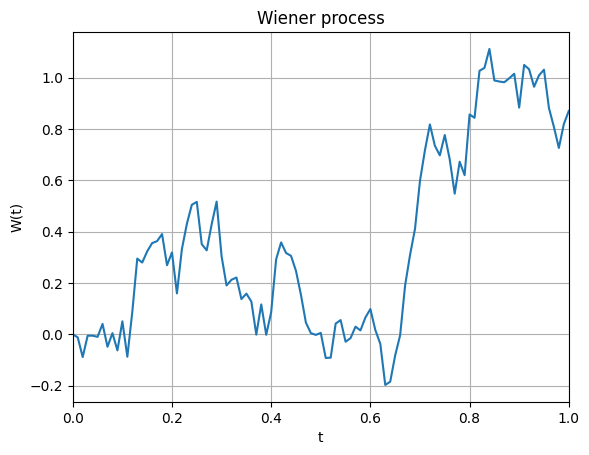

In [111]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

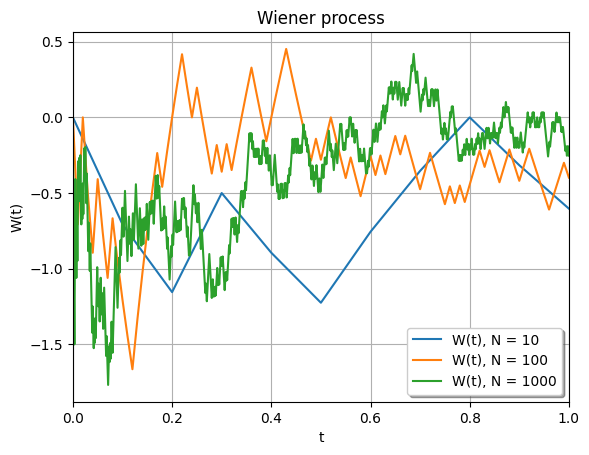

In [112]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

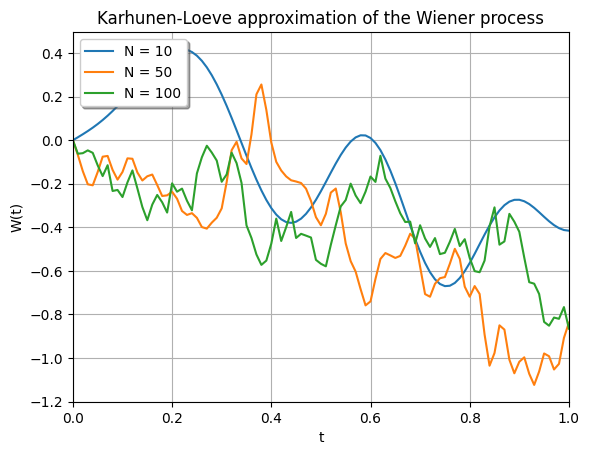

In [113]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data))
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

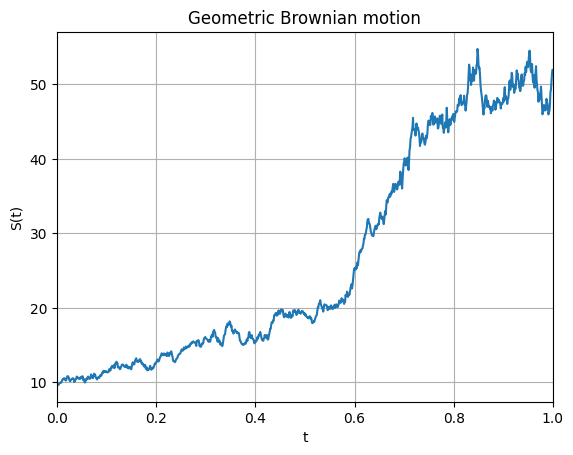

In [114]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

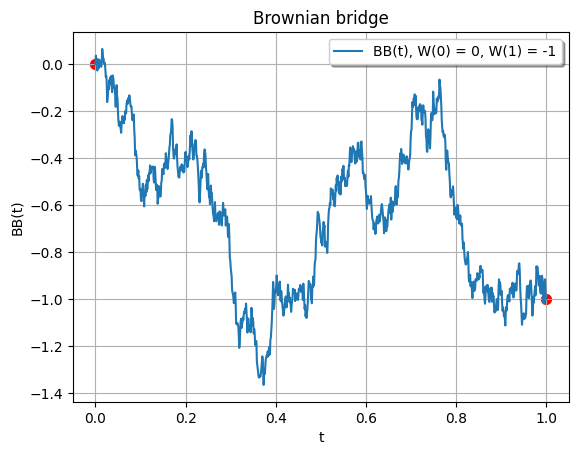

In [115]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

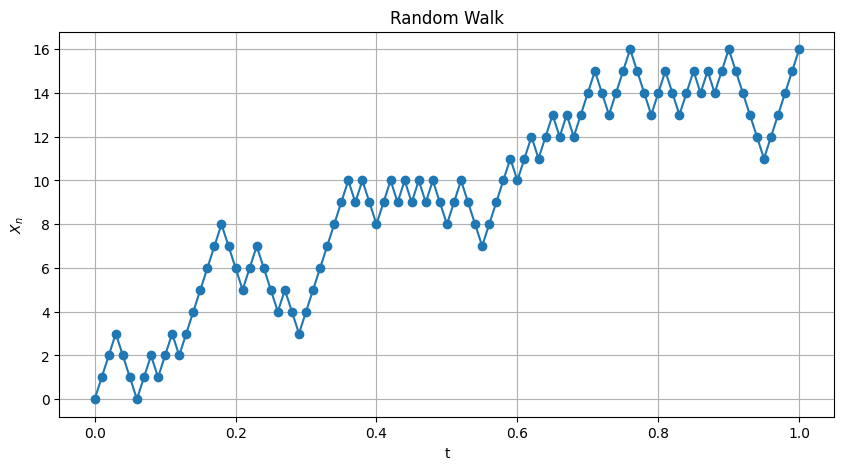

In [116]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

RandomWalk(100)

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


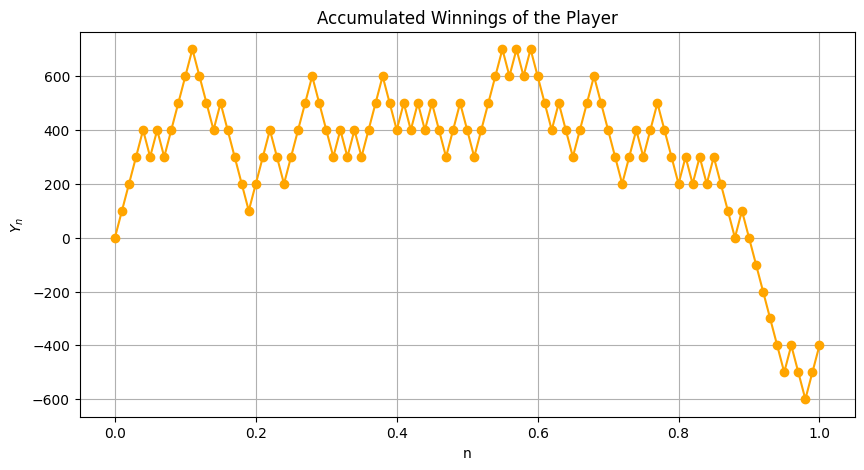

In [117]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

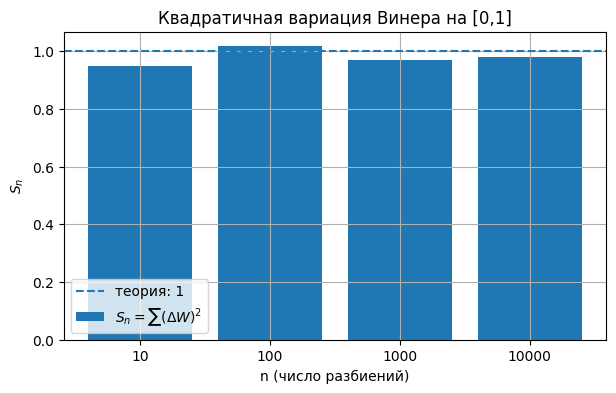

In [118]:
Ns = [10, 100, 1000, 10000]
S = []

for n in Ns:
    t_data, w_data = WienerProcess(n, 1)
    Sn = np.sum(np.diff(w_data)**2)
    S.append(Sn)

plt.figure(figsize=(7,4))
groups=[str(n) for n in Ns]
plt.bar(groups, S, label=r"$S_n=\sum (\Delta W)^2$")
plt.axhline(1, linestyle='--', label="теория: 1")
plt.xlabel("n (число разбиений)")
plt.ylabel(r"$S_n$")
plt.title("Квадратичная вариация Винера на [0,1]")
plt.grid(True)
plt.legend()
plt.show()

Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [125]:
M=500
list_half=[]
list_end=[]
N=100
h=int(N/2)
for n in range(M):
  t_data, w_data = WienerProcess(N, 1)
  list_half.append(w_data[h])
  list_end.append(w_data[-1])

c=np.cov(list_half,list_end)
print(c[0,1])

0.46151460843877007


Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапазон влияет на результат.

In [120]:
#500 траекторий мало, чтобы увидеть результат
M=5000
a=0.3
eps=0.01
N=100
s=int(0.4*N)
s_true=[]
for n in range(M):
  t_data, w_data = WienerProcess(N, 1)
  if (a-eps<=w_data[s]<=a+eps):
    s_true.append(w_data[-1])

m=np.mean(s_true)
print(m)

0.2845189983146127


Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

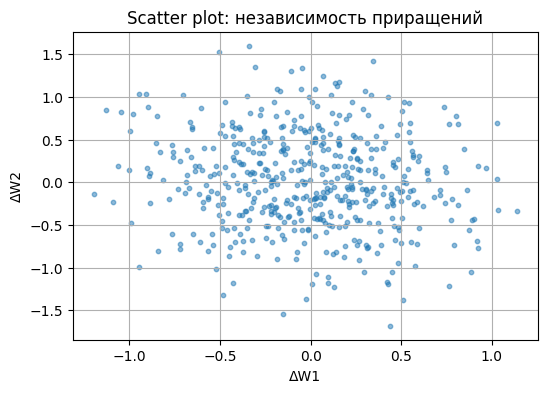

-0.026049365710432162


In [127]:
M=500
N=100
t1=int(0.1*N)
t2=int(0.3*N)
t3=int(0.7*N)
t4=N
dW1=[]
dW2=[]

for n in range(M):
  t_data, w_data = WienerProcess(N, 1)
  dW1.append(w_data[t2]-w_data[t1])
  dW2.append(w_data[t4]-w_data[t3])


plt.figure(figsize=(6,4))
plt.scatter(dW1, dW2, alpha=0.5, s=10)
plt.xlabel("ΔW1")
plt.ylabel("ΔW2")
plt.title("Scatter plot: независимость приращений")
plt.grid(True)
plt.show()

l=np.cov(dW1, dW2)
print(l[0,1])

Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


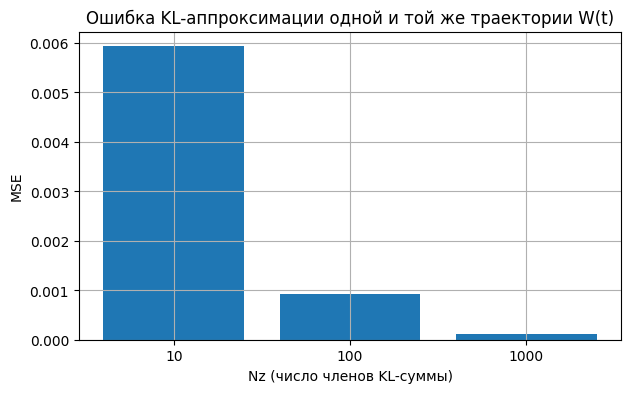

In [141]:
import numpy as np
import matplotlib.pyplot as plt

def phi(k, t, T=1.0):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def lambda_k(k, T=1.0):
    # собственные числа для ядра min(s,t)
    return 4 * T**2 / ((2 * k + 1)**2 * np.pi**2)


T = 1.0
Nt = 1000
Nzs = [10, 100, 1000]


t_data, w_data = WienerProcess(Nt, T)
dt = T / Nt


maxNz = max(Nzs)
k_all = np.arange(maxNz)  # 0..maxNz-1
Phi = phi(k_all[:, None], t_data[None, :], T)  # shape: (maxNz, Nt+1)
lam = lambda_k(k_all, T)                        # shape: (maxNz,)

# 3) находим коэффициенты проекции c_k для аппроксимации w(t) = sum c_k * phi_k(t)
#    так как <phi_k, phi_k> = lambda_k, то c_k = <w,phi_k>/lambda_k
inner = (Phi * w_data[None, :]).sum(axis=1) * dt   # <w, phi_k> приближённо
c_all = inner / lam                                # коэффициенты c_k


MSE = []
for Nz in Nzs:
    w_approx = (c_all[:Nz, None] * Phi[:Nz, :]).sum(axis=0)  # восстановление по Nz модам
    mse = np.mean((w_data - w_approx)**2)
    MSE.append(mse)


x = np.arange(len(Nzs))
plt.figure(figsize=(7,4))
plt.bar(x, MSE)
plt.xticks(x, [str(n) for n in Nzs])
plt.xlabel("Nz (число членов KL-суммы)")
plt.ylabel("MSE")
plt.title("Ошибка KL-аппроксимации одной и той же траектории W(t)")
plt.grid(True)
plt.show()